#### Prepared for Gabor's Data Analysis

### Data Analysis for Business, Economics, and Policy
by Gabor Bekes and  Gabor Kezdi
 
Cambridge University Press 2021

**[gabors-data-analysis.com ](https://gabors-data-analysis.com/)**

 License: Free to share, modify and use for educational purposes. 
 Not to be used for commercial purposes.

### CHAPTER 22
**CH22A How does a merger between airlines affect prices?**

 using the airline-tickets-usa dataset
 
 version 1.0 2021-05-05

In [1]:
import os
import sys
import warnings
from datetime import datetime as dt

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from IPython.core.display import HTML
from mizani.formatters import percent_format
from mizani.formatters import date_format
from plotnine import *
from stargazer.stargazer import Stargazer

import seaborn as sns
from datetime import datetime as dt

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


warnings.filterwarnings("ignore")


# I.  Examining pre-treatment trends in avg ln price

workfile to identify treated and untreated markets

use year-quarter panel data and merge to it treated-untreated 

(keep matched ones; no unmatched from "using")

In [2]:
data = pd.read_pickle("/workspaces/codespaces-jupyter/data/ch22-air_final.pkl")

In [21]:
# First, create the market_price_size column based on the avgprice
data["small"] = data["avgprice"] < 290
data["medium"] = (data["avgprice"] >= 290) & (data["avgprice"] < 520)
data["large"] = data["avgprice"] >= 520
data["market_price_size"] = np.select(
    [data["small"],
     data["medium"],
     data["large"]],
    ["cheap", "medium", "expensive"],
)

aggreagete data to create average price by treated-untreated and year-quarter and draw time series graphs of log avg price all markets

In [3]:
weighted_avg = lambda x: np.average(x, weights=data.loc[x.index, "passengers"])

In [16]:
data_agg = (
    data.groupby(["treated", "year", "quarter"])
    .agg(avgprice=("avgprice", weighted_avg))
    .reset_index()
)

data_agg["lnavgprice"] = np.log(data_agg["avgprice"])
data_agg["quarters"] = (
    data_agg["year"].astype(str) + " Q" + data_agg["quarter"].astype(str)
)

# Create date values for plotting - convert year and quarter to proper datetime
data_agg["date"] = pd.to_datetime(
    data_agg["year"].astype(str) + "Q" + data_agg["quarter"].astype(str)
)

data_agg["small"] = data_agg["avgprice"] < 290
data_agg["medium"] = (data_agg["avgprice"] >= 290) & (data_agg["avgprice"] < 520)
data_agg["large"] = data_agg["avgprice"] >= 520
data_agg["market_price_size"] = np.select(
    [data_agg["small"],
     data_agg["medium"],
     data_agg["large"]],
    ["cheap", "medium", "expensive"],)

In [17]:
data_agg.head()

,treated,year,quarter,avgprice,lnavgprice,quarters,date,small,medium,large,market_price_size
0,False,2010,2,195.457794,5.275344,2010 Q2,2010-04-01,True,False,False,cheap
1,False,2010,3,190.954483,5.252035,2010 Q3,2010-07-01,True,False,False,cheap
2,False,2010,4,192.923080,5.262291,2010 Q4,2010-10-01,True,False,False,cheap
3,False,2011,1,214.151733,5.366685,2011 Q1,2011-01-01,True,False,False,cheap
4,False,2011,2,212.308273,5.358039,2011 Q2,2011-04-01,True,False,False,cheap


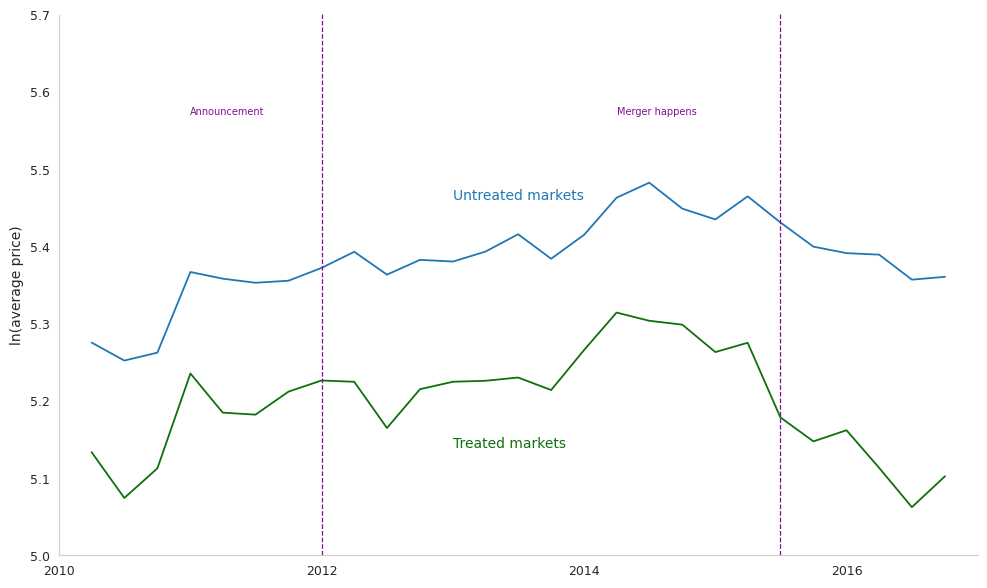

In [12]:
# Setup the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Define colors
colors = ['#1F77B4', "#0E700B", "#880B9B"]  # blue, orange, green

# Plot treated and untreated markets
for i, treated_val in enumerate([False, True]):
        subset = data_agg[data_agg['treated'] == treated_val]
        ax.plot(subset['date'], subset['lnavgprice'], 
                        linewidth=1.3, 
                        color=colors[i], 
                        label='Treated markets' if treated_val else 'Untreated markets')

# Add vertical lines for announcement and merger
announcement_date = data_agg.loc[data_agg['quarters'] == '2012 Q1', 'date'].values[0]
merger_date = data_agg.loc[data_agg['quarters'] == '2015 Q3', 'date'].values[0]
ax.axvline(x=announcement_date, color=colors[2], linestyle='--', linewidth=0.9)
ax.axvline(x=merger_date, color=colors[2], linestyle='--', linewidth=0.9)

# Add text annotations
text_date = data_agg.loc[data_agg['quarters'] == '2013 Q1', 'date'].values[0]
ax.text(text_date, 5.14, 'Treated markets', color=colors[1], fontsize=10)
ax.text(text_date, 5.46, 'Untreated markets', color=colors[0], fontsize=10)

ax.text(data_agg.loc[data_agg['quarters'] == '2011 Q1', 'date'].values[0], 
                5.57, 'Announcement', color=colors[2], fontsize=7)
ax.text(data_agg.loc[data_agg['quarters'] == '2014 Q2', 'date'].values[0], 
                5.57, 'Merger happens', color=colors[2], fontsize=7)

# Set axis limits and formatting
ax.set_xlim(dt.strptime("2010-01-01", "%Y-%m-%d"), dt.strptime("2017-01-01", "%Y-%m-%d"))
ax.set_ylim(5, 5.6)
ax.set_yticks(np.arange(5.0, 5.7, 0.1))
ax.set_yticklabels([f'{y:.1f}' for y in np.arange(5.0, 5.7, 0.1)])

# Format x-axis dates
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Add labels and styling
ax.set_ylabel('ln(average price)')
ax.grid(False)
plt.tight_layout()

# Apply clean theme
sns.set_style("whitegrid", {'axes.grid': False})
ax.tick_params(axis='both', which='major', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


### Creating markets based on their price

In [19]:
data_agg.head()

,treated,year,quarter,avgprice,lnavgprice,quarters,date,small,medium,large,market_price_size
0,False,2010,2,195.457794,5.275344,2010 Q2,2010-04-01,True,False,False,cheap
1,False,2010,3,190.954483,5.252035,2010 Q3,2010-07-01,True,False,False,cheap
2,False,2010,4,192.923080,5.262291,2010 Q4,2010-10-01,True,False,False,cheap
3,False,2011,1,214.151733,5.366685,2011 Q1,2011-01-01,True,False,False,cheap
4,False,2011,2,212.308273,5.358039,2011 Q2,2011-04-01,True,False,False,cheap


**Cheap price markets**

In [74]:
data_agg_cheap = (
    data.query("market_price_size == 'cheap'")
    .groupby(["treated", "year", "quarter"])
    .agg(avgprice=("avgprice", weighted_avg))
    .reset_index()
)

data_agg_cheap["lnavgprice"] = np.log(data_agg_cheap["avgprice"])
data_agg_cheap["quarters"] = (
    data_agg_cheap["year"].astype(str) + " Q" + data_agg_cheap["quarter"].astype(str)
)
# Create proper datetime by constructing a string in the format YYYYQN
data_agg_cheap["date"] = pd.to_datetime(
    data_agg_cheap["year"].astype(str) + "Q" + data_agg_cheap["quarter"].astype(str)
)
data_agg_cheap.head()


,treated,year,quarter,avgprice,lnavgprice,quarters,date
0,False,2010,2,108.459679,4.686378,2010 Q2,2010-04-01
1,False,2010,3,105.225899,4.656109,2010 Q3,2010-07-01
2,False,2010,4,110.992416,4.709462,2010 Q4,2010-10-01
3,False,2011,1,118.678772,4.776421,2011 Q1,2011-01-01
4,False,2011,2,114.031502,4.736475,2011 Q2,2011-04-01


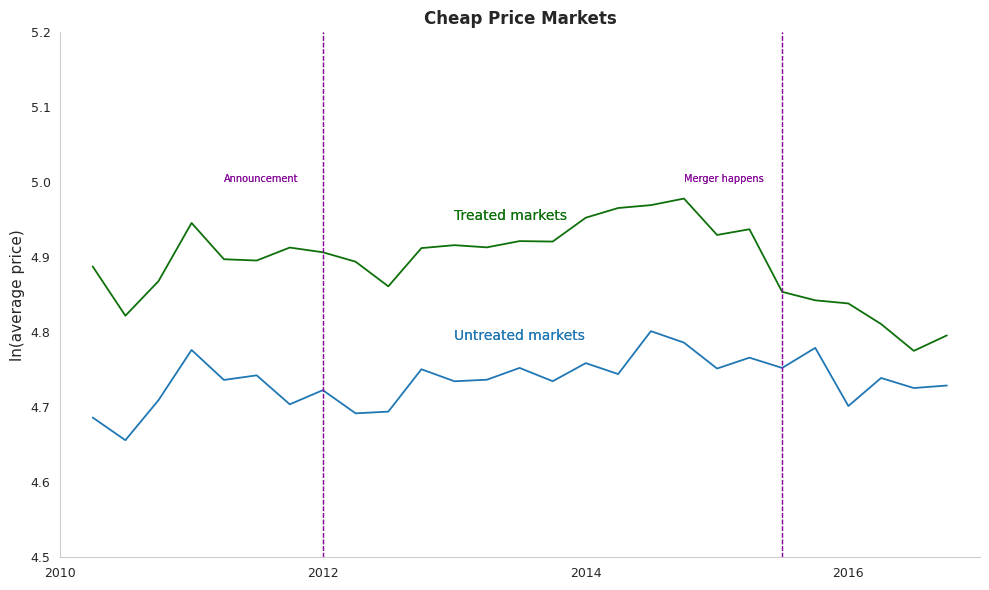

In [81]:
# Setup the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Define colors
colors = ['#1F77B4', "#0E700B", "#880B9B"] 

# Plot treated and untreated markets
for i, treated_val in enumerate([False, True]):
        subset = data_agg_cheap[data_agg_cheap['treated'] == treated_val]
        ax.plot(subset['date'], subset['lnavgprice'], 
                                        linewidth=1.3, 
                                        color=colors[i], 
                                        label='Treated markets' if treated_val else 'Untreated markets')

        # Add vertical lines for announcement and merger
        announcement_date = data_agg_cheap.loc[data_agg_cheap['quarters'] == '2012 Q1', 'date'].values[0]
        merger_date = data_agg_cheap.loc[data_agg_cheap['quarters'] == '2015 Q3', 'date'].values[0]
        ax.axvline(x=announcement_date, color=colors[2], linestyle='--', linewidth=0.9)
        ax.axvline(x=merger_date, color=colors[2], linestyle='--', linewidth=0.9)

        # Add text annotations - adjusted position for cheap markets
        text_date = data_agg_cheap.loc[data_agg_cheap['quarters'] == '2013 Q1', 'date'].values[0]
        ax.text(text_date, 4.95, 'Treated markets', color=colors[1], fontsize=10)
        ax.text(text_date, 4.79, 'Untreated markets', color=colors[0], fontsize=10)

        # Add annotation for vertical lines
        ax.text(data_agg_cheap.loc[data_agg_cheap['quarters'] == '2011 Q2', 'date'].values[0], 
                        5.0, 'Announcement', color=colors[2], fontsize=7)
        ax.text(data_agg_cheap.loc[data_agg_cheap['quarters'] == '2014 Q4', 'date'].values[0], 
                        5.0, 'Merger happens', color=colors[2], fontsize=7)

        # Set axis limits and formatting - adjusted for cheap markets
        ax.set_xlim(dt.strptime("2010-01-01", "%Y-%m-%d"), dt.strptime("2017-01-01", "%Y-%m-%d"))
        ax.set_ylim(4.5, 5.2)

        # Create evenly spaced ticks
        y_ticks = np.arange(4.5, 5.2, 0.1)
        ax.set_yticks(y_ticks)
        ax.set_yticklabels([f'{y:.1f}' for y in y_ticks])

        # Format x-axis dates
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

      # Add labels and styling
        ax.set_ylabel('ln(average price)', fontsize=11)
        ax.set_title('Cheap Price Markets', fontsize=12, fontweight='bold')
        ax.grid(False)
        plt.tight_layout()

        # Apply clean theme
        sns.set_style("whitegrid", {'axes.grid': False})
        ax.tick_params(axis='both', which='major', labelsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)


**Medium price markets**

In [82]:
data_agg_medium = (
    data.query("market_price_size == 'medium'")
    .groupby(["treated", "year", "quarter"])
    .agg(avgprice=("avgprice", weighted_avg))
    .reset_index()
)

data_agg_medium["lnavgprice"] = np.log(data_agg_medium["avgprice"])
data_agg_medium["quarters"] = (
    data_agg_medium["year"].astype(str) + " Q" + data_agg_medium["quarter"].astype(str)
)
# Create date values for plotting - convert year and quarter to proper datetime
data_agg_medium["date"] = pd.to_datetime(
    data_agg_medium["year"].astype(str) + "Q" + data_agg_medium["quarter"].astype(str)
)
data_agg_medium.head()

,treated,year,quarter,avgprice,lnavgprice,quarters,date
0,False,2010,2,378.757690,5.936897,2010 Q2,2010-04-01
1,False,2010,3,379.068481,5.937717,2010 Q3,2010-07-01
2,False,2010,4,375.770721,5.928979,2010 Q4,2010-10-01
3,False,2011,1,383.151886,5.948431,2011 Q1,2011-01-01
4,False,2011,2,385.922150,5.955636,2011 Q2,2011-04-01


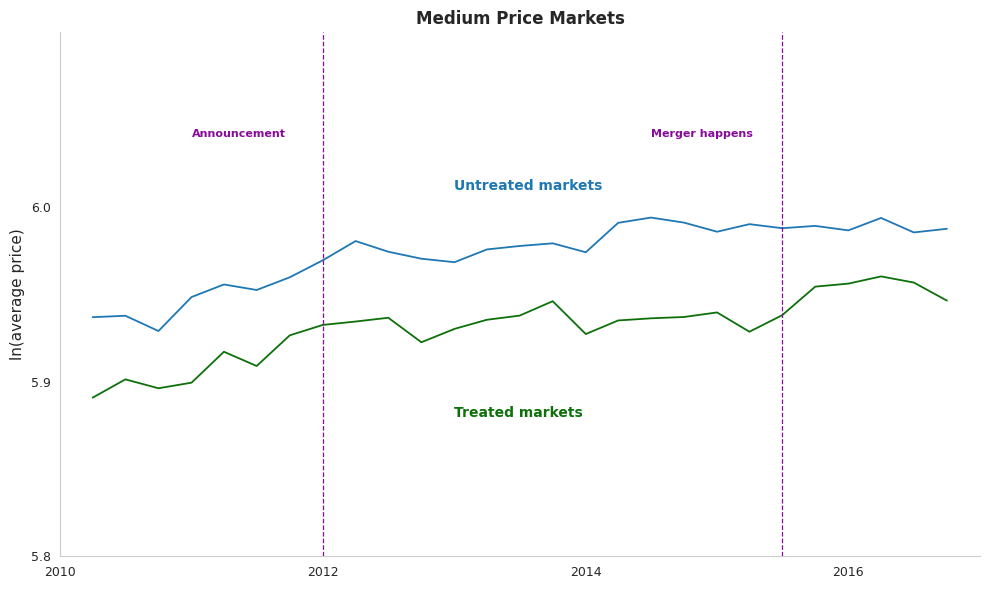

In [107]:
# Setup the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Define colors
colors = ['#1F77B4', "#0E700B", "#880B9B"]  # blue, green, purple

# Plot treated and untreated markets
for i, treated_val in enumerate([False, True]):
        subset = data_agg_medium[data_agg_medium['treated'] == treated_val]
        ax.plot(subset['date'], subset['lnavgprice'], 
                        linewidth=1.3, 
                        color=colors[i], 
                        label='Treated markets' if treated_val else 'Untreated markets')

# Add vertical lines for announcement and merger
announcement_date = data_agg_medium.loc[data_agg_medium['quarters'] == '2012 Q1', 'date'].values[0]
merger_date = data_agg_medium.loc[data_agg_medium['quarters'] == '2015 Q3', 'date'].values[0]
ax.axvline(x=announcement_date, color=colors[2], linestyle='--', linewidth=0.9)
ax.axvline(x=merger_date, color=colors[2], linestyle='--', linewidth=0.9)

# Add text annotations - adjusted for medium markets
text_date = data_agg_medium.loc[data_agg_medium['quarters'] == '2013 Q1', 'date'].values[0]
ax.text(text_date, 5.88, 'Treated markets', color=colors[1], fontsize=10, fontweight='bold')
ax.text(text_date, 6.01, 'Untreated markets', color=colors[0], fontsize=10, fontweight='bold')

# Add annotation for vertical lines with better positioning
ax.text(data_agg_medium.loc[data_agg_medium['quarters'] == '2011 Q1', 'date'].values[0], 
                6.04, 'Announcement', color=colors[2], fontsize=8, fontweight='bold')
ax.text(data_agg_medium.loc[data_agg_medium['quarters'] == '2014 Q3', 'date'].values[0], 
                6.04, 'Merger happens', color=colors[2], fontsize=8, fontweight='bold')

# Set axis limits and formatting - adjusted for medium markets
ax.set_xlim(dt.strptime("2010-01-01", "%Y-%m-%d"), dt.strptime("2017-01-01", "%Y-%m-%d"))
ax.set_ylim(5.8, 6.1)

# Create more evenly spaced ticks for better readability
y_ticks = np.arange(5.8, 6.1, 0.1)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{y:.1f}' for y in y_ticks], fontsize=9)

# Format x-axis dates
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Add labels and styling
ax.set_ylabel('ln(average price)', fontsize=11)
ax.set_title('Medium Price Markets', fontsize=12, fontweight='bold')
ax.grid(False)
plt.tight_layout()

# Apply clean theme
sns.set_style("whitegrid", {'axes.grid': False})
ax.tick_params(axis='both', which='major', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


**Large price markets**

In [108]:
data_agg_expensive = (
    data.query("market_price_size == 'expensive'")
    .groupby(["treated", "year", "quarter"])
    .agg(avgprice=("avgprice", weighted_avg))
    .reset_index()
)

data_agg_expensive["lnavgprice"] = np.log(data_agg_expensive["avgprice"])
data_agg_expensive["quarters"] = (
    data_agg_expensive["year"].astype(str) + " Q" + data_agg_expensive["quarter"].astype(str)
)
# Create date values for plotting - convert year and quarter to proper datetime
data_agg_expensive["date"] = pd.to_datetime(
    data_agg_expensive["year"].astype(str) + "Q" + data_agg_expensive["quarter"].astype(str)
)
data_agg_expensive.head()

,treated,year,quarter,avgprice,lnavgprice,quarters,date
0,False,2010,2,661.151794,6.493983,2010 Q2,2010-04-01
1,False,2010,3,655.839172,6.485916,2010 Q3,2010-07-01
2,False,2010,4,659.142212,6.490939,2010 Q4,2010-10-01
3,False,2011,1,666.045532,6.501358,2011 Q1,2011-01-01
4,False,2011,2,656.148682,6.486387,2011 Q2,2011-04-01


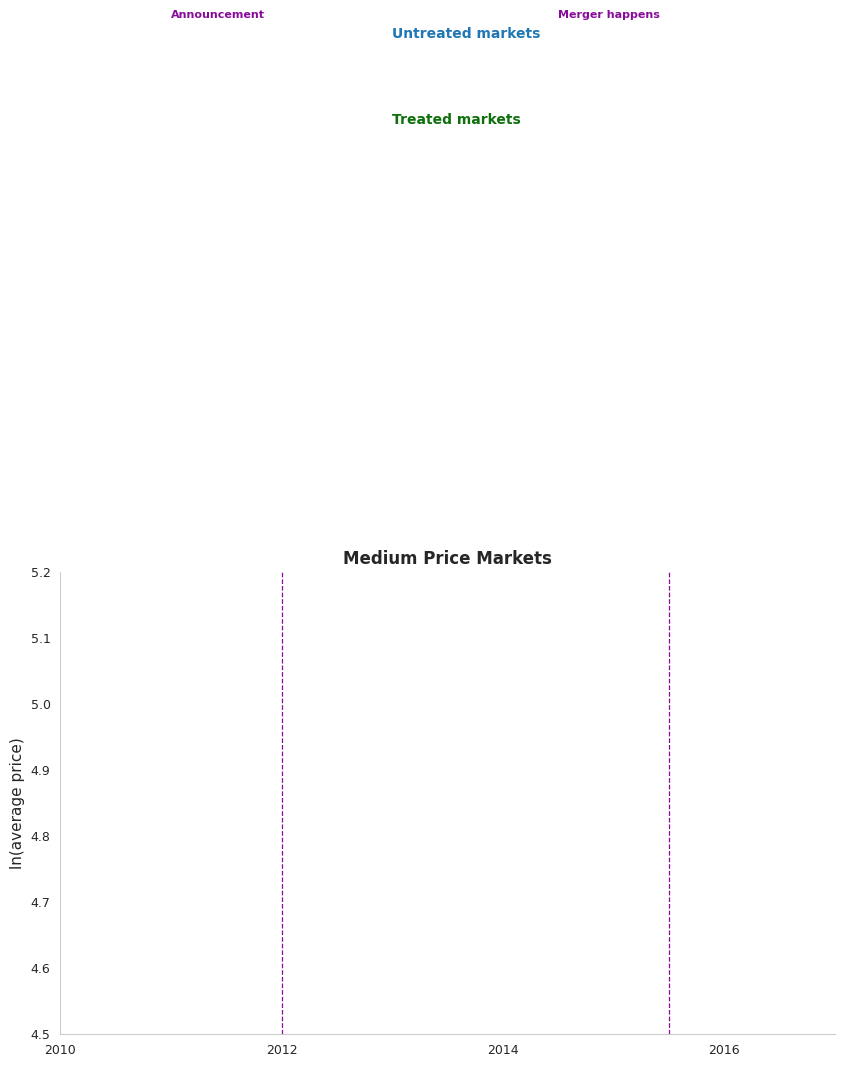

In [111]:
# Setup the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Define colors
colors = ['#1F77B4', "#0E700B", "#880B9B"]  # blue, green, purple

# Plot treated and untreated markets
for i, treated_val in enumerate([False, True]):
        subset = data_agg_expensive[data_agg_expensive['treated'] == treated_val]
        ax.plot(subset['date'], subset['lnavgprice'], 
                        linewidth=1.3, 
                        color=colors[i], 
                        label='Treated markets' if treated_val else 'Untreated markets')

# Add vertical lines for announcement and merger
announcement_date = data_agg_expensive.loc[data_agg_expensive['quarters'] == '2012 Q1', 'date'].values[0]
merger_date = data_agg_expensive.loc[data_agg_expensive['quarters'] == '2015 Q3', 'date'].values[0]
ax.axvline(x=announcement_date, color=colors[2], linestyle='--', linewidth=0.9)
ax.axvline(x=merger_date, color=colors[2], linestyle='--', linewidth=0.9)

# Add text annotations - adjusted for medium markets
text_date = data_agg_expensive.loc[data_agg_expensive['quarters'] == '2013 Q1', 'date'].values[0]
ax.text(text_date, 5.88, 'Treated markets', color=colors[1], fontsize=10, fontweight='bold')
ax.text(text_date, 6.01, 'Untreated markets', color=colors[0], fontsize=10, fontweight='bold')

# Add annotation for vertical lines with better positioning
ax.text(data_agg_expensive.loc[data_agg_expensive['quarters'] == '2011 Q1', 'date'].values[0], 
                6.04, 'Announcement', color=colors[2], fontsize=8, fontweight='bold')
ax.text(data_agg_expensive.loc[data_agg_expensive['quarters'] == '2014 Q3', 'date'].values[0], 
                6.04, 'Merger happens', color=colors[2], fontsize=8, fontweight='bold')

# Set axis limits and formatting - adjusted for cheap markets
ax.set_xlim(dt.strptime("2010-01-01", "%Y-%m-%d"), dt.strptime("2017-01-01", "%Y-%m-%d"))
ax.set_ylim(4.5, 5.2)

# Create evenly spaced ticks
y_ticks = np.arange(4.5, 5.2, 0.1)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{y:.1f}' for y in y_ticks])

# Format x-axis dates
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Add labels and styling
ax.set_ylabel('ln(average price)', fontsize=11)
ax.set_title('Medium Price Markets', fontsize=12, fontweight='bold')
ax.grid(False)
plt.tight_layout()

# Apply clean theme
sns.set_style("whitegrid", {'axes.grid': False})
ax.tick_params(axis='both', which='major', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# II. ANALYSIS
**Basic (First) diff-in-diffs regression, weighted by # passengers on market, in before period**

In [5]:
# reload main file
data_agg = pd.read_pickle("/workspaces/codespaces-jupyter/data/ch22-airline-workfile.pkl")
data_agg

,origin,finaldest,return,year,airports,return_sym,stops,ptotalAA,ptotalUS,ptotallargest,...,pass_bef_id,pass_aft_id,pass_bef,pass_aft,balanced,treated,untreated,smallmkt,lnavgp,d_lnavgp
0,ABE,ABE,1,2011,9,0.0,3,0.0,0.0,1.0,...,1.0,NaN,1.0,NaN,False,NaN,NaN,NaN,5.117994,NaN
1,ABE,ABI,0,2011,4,NaN,2,0.0,0.0,1.0,...,1.0,NaN,1.0,NaN,False,NaN,NaN,NaN,6.834109,NaN
2,ABE,ABI,1,2011,7,1.0,2,0.0,0.0,2.0,...,2.0,NaN,2.0,5.0,True,False,True,True,6.604621,NaN
3,ABE,ABI,1,2016,7,1.0,2,3.0,0.0,4.0,...,NaN,5.0,2.0,5.0,True,False,True,True,6.604215,-0.000406
4,ABE,ABQ,0,2011,3,NaN,1,0.0,0.0,13.0,...,23.0,NaN,23.0,11.0,True,False,True,True,5.818663,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277605,YUM,XNA,1,2016,7,1.0,2,0.0,0.0,5.0,...,NaN,5.0,5.0,5.0,True,False,True,True,6.451102,0.523110
277606,YUM,YKM,0,2011,4,NaN,2,0.0,0.0,2.0,...,2.0,NaN,2.0,2.0,True,False,True,True,5.547129,NaN
277607,YUM,YKM,0,2016,4,NaN,2,0.0,0.0,2.0,...,NaN,2.0,2.0,2.0,True,False,True,True,5.339939,-0.207190
277608,YUM,YKM,1,2011,7,1.0,2,0.0,0.0,2.0,...,2.0,NaN,2.0,2.0,True,False,True,True,6.271933,NaN


In [22]:
# keep balanced
data_balanced = data_agg.query("balanced == 1")
data_balanced

,origin,finaldest,return,year,airports,return_sym,stops,ptotalAA,ptotalUS,ptotallargest,...,pass_bef_id,pass_aft_id,pass_bef,pass_aft,balanced,treated,untreated,smallmkt,lnavgp,d_lnavgp
2,ABE,ABI,1,2011,7,1.0,2,0.0,0.0,2.0,...,2.0,NaN,2.0,5.0,True,False,True,True,6.604621,NaN
3,ABE,ABI,1,2016,7,1.0,2,3.0,0.0,4.0,...,NaN,5.0,2.0,5.0,True,False,True,True,6.604215,-0.000406
4,ABE,ABQ,0,2011,3,NaN,1,0.0,0.0,13.0,...,23.0,NaN,23.0,11.0,True,False,True,True,5.818663,NaN
5,ABE,ABQ,0,2016,4,NaN,2,1.0,0.0,5.0,...,NaN,11.0,23.0,11.0,True,False,True,True,6.006129,0.187466
6,ABE,ABQ,1,2011,5,0.0,1,0.0,1.0,38.0,...,76.0,NaN,76.0,33.0,True,False,True,True,6.038091,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277605,YUM,XNA,1,2016,7,1.0,2,0.0,0.0,5.0,...,NaN,5.0,5.0,5.0,True,False,True,True,6.451102,0.523110
277606,YUM,YKM,0,2011,4,NaN,2,0.0,0.0,2.0,...,2.0,NaN,2.0,2.0,True,False,True,True,5.547129,NaN
277607,YUM,YKM,0,2016,4,NaN,2,0.0,0.0,2.0,...,NaN,2.0,2.0,2.0,True,False,True,True,5.339939,-0.207190
277608,YUM,YKM,1,2011,7,1.0,2,0.0,0.0,2.0,...,2.0,NaN,2.0,2.0,True,False,True,True,6.271933,NaN


In [33]:
data_balanced[data_balanced["year"] == 2011][["market", "avgprice"]].describe().T

,count,mean,std,min,25%,50%,75%,max
avgprice,113047.0,434.854381,242.851948,0.0,282.0,402.166667,537.565714,4879.0


In [40]:
data_balanced["small"] = data_balanced["avgprice"] < 290
data_balanced["medium"] = (data_balanced["avgprice"] >= 290) & (data_balanced["avgprice"] < 520)
data_balanced["large"] = data_balanced["avgprice"] >= 520
data_balanced["market_price_size"] = np.select(
    [data_balanced["small"],
     data_balanced["medium"],
     data_balanced["large"]],
    ["small", "medium", "large"])
data_balanced["market_price_size"].value_counts()

market_price_size
medium    102917
large      67053
small      56124
Name: count, dtype: int64

In [4]:
data_balanced

NameError: name 'data_balanced' is not defined

In [42]:
fd_all = smf.wls("d_lnavgp ~ treated", data_balanced, weights=data_balanced["pass_bef"]).fit(cov_type="HC0") 

# for cheap markets
fd_small = smf.wls("d_lnavgp ~ treated",data_balanced.query("small == 1"),weights=data_balanced.query("small == 1")["pass_bef"],
).fit(cov_type="HC0")


#for medium markets
fd_med = smf.wls("d_lnavgp ~ treated",data_balanced.query("medium == 1"),weights=data_balanced.query("medium == 1")["pass_bef"],
).fit(cov_type="HC0")

#for large markets
fd_large = smf.wls("d_lnavgp ~ treated",data_balanced.query("large == 1"),weights=data_balanced.query("large == 1")["pass_bef"],
).fit(cov_type="HC0")


Here we do First-differences setup (d_Y ~ treated):

In [44]:
fd_all.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:               d_lnavgp   R-squared:                       0.053
Model:                            WLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     325.6
Date:                Thu, 04 Sep 2025   Prob (F-statistic):           1.10e-72
Time:                        00:08:40   Log-Likelihood:            -1.9316e+05
No. Observations:              112632   AIC:                         3.863e+05
Df Residuals:                  112630   BIC:                         3.864e+05
Df Model:                           1                                         
Covariance Type:                  HC0                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.1565      0.007     23.311      0.000       0.143       0.170
treated[T.True]    -0.1795      0.010    -18.045      0.000      -0.199      -0.160
==============================================================================
Omnibus:                    43773.559   Durbin-Watson:                   1.537
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         18490714.482
Skew:                           0.505   Prob(JB):                         0.00
Kurtosis:                      65.762   Cond. No.                         2.94
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC0)
"""

Here is an example how to do Panel format (Y ~ treated + post + treated*post):


In [45]:
stargazer = Stargazer([fd_all, fd_small, fd_med, fd_large])
stargazer.rename_covariates({"Intercept": "Constant", "treated[T.True]": "American Airlines BEFORE"})
stargazer.custom_columns(["All markets", "Small markets", "Medium markets", "Large markets"], [1, 1, 1, 1])
HTML(stargazer.render_html())

In [49]:
import statsmodels.formula.api as smf

did_all = smf.wls(
	formula="lnavgp ~ treated + after + treated:after", 
	data=data_balanced,
	weights=data_balanced["pass_bef"]
).fit(cov_type="HC0")

did_s = smf.wls(
	formula="lnavgp ~ treated + after + treated:after", 
	data=data_balanced.query("small == 1"),
	weights=data_balanced.query("small == 1")["pass_bef"]
).fit(cov_type="HC0") 

did_m = smf.wls(
	formula="lnavgp ~ treated + after + treated:after", 
	data=data_balanced.query("medium == 1"),
	weights=data_balanced.query("medium == 1")["pass_bef"]
).fit(cov_type="HC0")

did_l = smf.wls(
	formula="lnavgp ~ treated + after + treated:after", 
	data=data_balanced.query("large == 1"),
	weights=data_balanced.query("large == 1")["pass_bef"]
).fit(cov_type="HC0")

In [63]:
stargazer = Stargazer([did_all, did_s, did_m, did_l])
stargazer.rename_covariates({"Intercept": "Baseline avg outcome - Intercept", 
                             "treated[T.True]": "Beta 1 - Fixed Effect - Baseline diff btwe Treated & Control BEFORE", 
                             "after": "Beta 2 - Time Effect", 
                             "treated[T.True]:after": "Beta 3 (DID Effect) - American Airlines BEFORE"})
stargazer.custom_columns(["All markets", "Cheap markets", "Medium markets", "Expensive markets"], [1, 1, 1, 1])
HTML(stargazer.render_html())

In [56]:
fd_constants = {
    "All Markets": fd_all.params['Intercept'],
    "Cheap Markets": fd_small.params['Intercept'],
    "Medium Markets": fd_med.params['Intercept'],
    "Expensive Markets": fd_large.params['Intercept']   
}

# Convert intercepts from log to percent price levels
fd_constants_percent = {
    model: (np.exp(constant) - 1) * 100
    for model, constant in fd_constants.items()
}


print("Interpretation of Intercepts (Constants):\n")
for model, percent in fd_constants_percent.items():
    print(f"In {model}, the average baseline price in the control group AFTER the merger is approximately {percent:.2f}% higher than the reference level (e.g., baseline of 0).")

Interpretation of Intercepts (Constants):

In All Markets, the average baseline price in the control group AFTER the merger is approximately 16.94% higher than the reference level (e.g., baseline of 0).
In Cheap Markets, the average baseline price in the control group AFTER the merger is approximately 12.62% higher than the reference level (e.g., baseline of 0).
In Medium Markets, the average baseline price in the control group AFTER the merger is approximately 24.23% higher than the reference level (e.g., baseline of 0).
In Expensive Markets, the average baseline price in the control group AFTER the merger is approximately 26.23% higher than the reference level (e.g., baseline of 0).


In [ ]:
fd_slopes = {
    "All Markets": fd_all.params["treated[T.True]"],
    "Cheap Markets": fd_small.params["treated[T.True]"],
    "Medium Markets": fd_med.params["treated[T.True]"],
    "Expensive Markets": fd_large.params["treated[T.True]"]
}

# Step 2: Compute price differences
fd_interpretation = {}

for model in fd_constants:
    const = fd_constants[model]
    slope = fd_slopes[model]

    untreated_price = np.exp(const)
    treated_price = np.exp(const + slope)

    untreated_growth = untreated_price - 1
    treated_growth = treated_price - 1

    # Difference in growth
    less_growth = (untreated_growth - treated_growth) / untreated_growth * 100

    # Actual change in treated group
    treated_change_pct = (treated_price - 1) * 100

    fd_interpretation[model] = {
        "less_growth": less_growth,
        "treated_change": treated_change_pct
    }


print("Interpretation of Treatment Effects:\n")
for model, result in fd_interpretation.items():
    growth_gap = result["less_growth"]
    treated_change = result["treated_change"]

    direction = "increased" if treated_change > 0 else "dropped"
    print(f"In {model}, price in treated markets increased by {growth_gap:.2f}% less on average compared to untreated markets. In treated markets, prices actually {direction} by approximately {abs(treated_change):.2f}%.")

Interpretation of Treatment Effects:

In All Markets, price in treated markets increased by 113.43% less on average compared to untreated markets. IN treated markets, prices actually dropped by approximately 2.27%.
In Small Markets, price in treated markets increased by 118.92% less on average compared to untreated markets. IN treated markets, prices actually dropped by approximately 2.76%.
In Large Markets, price in treated markets increased by 106.43% less on average compared to untreated markets. IN treated markets, prices actually dropped by approximately 1.72%.


In [64]:
models = {
    "All Markets": did_all,
    "Cheap Markets": did_s,
    "Medium Markets": did_m,
    "Expensive Markets": did_l
}

interpretation_results = {}

for name, model in models.items():
    params = model.params

    # Coefficients
    intercept = params["Intercept"]               # β₀
    beta1 = params["treated[T.True]"]             # β₁
    beta2 = params["after"]                       # β₂
    beta3 = params["treated[T.True]:after"]       # β₃

    # 1. β₀: Baseline price level for untreated markets BEFORE merger
    base_untreated = np.exp(intercept)

    # 2. β₁: Difference in price BETWEEN treated and untreated BEFORE merger
    base_treated = np.exp(intercept + beta1)
    baseline_gap = (base_treated - base_untreated) / base_untreated * 100

    # 3. β₂: Change in untreated group over time (pre vs post)
    untreated_after = np.exp(intercept + beta2)
    untreated_growth = (untreated_after - base_untreated) / base_untreated * 100

    # 4. β₁ + β₃: Change in treated group over time (pre vs post)
    treated_after = np.exp(intercept + beta1 + beta2 + beta3)
    treated_growth = (treated_after - base_treated) / base_treated * 100

    # 5. β₃: Difference-in-Differences estimate (how much more or less treated changed)
    did_effect = treated_growth - untreated_growth

    interpretation_results[name] = {
        "baseline_gap": baseline_gap,
        "untreated_growth": untreated_growth,
        "treated_growth": treated_growth,
        "did_effect": did_effect
    }

# 🔍 Output interpretation
print("🧾 Full Interpretation of DID Coefficients:\n")
for name, result in interpretation_results.items():
    print(f"📊 {name}:")

    # β₁
    if result["baseline_gap"] > 0:
        print(f" - β₁ (treated): Before the merger, treated markets had {result['baseline_gap']:.2f}% higher prices than control markets.")
    else:
        print(f" - β₁ (treated): Before the merger, treated markets had {abs(result['baseline_gap']):.2f}% lower prices than control markets.")

    # β₂
    print(f" - β₂ (after): Over time, control (untreated) markets experienced a {result['untreated_growth']:.2f}% increase in price.")

    # β₁ + β₃
    print(f" - β₁ + β₃ (treated post): Treated markets changed by {result['treated_growth']:.2f}% after the merger.")

    # β₃
    if result["did_effect"] < 0:
        print(f" - β₃ (DID estimate): Prices in treated markets grew {abs(result['did_effect']):.2f}% less than control markets.")
    else:
        print(f" - β₃ (DID estimate): Prices in treated markets grew {result['did_effect']:.2f}% more than control markets.")

    print()

🧾 Full Interpretation of DID Coefficients:

📊 All Markets:
 - β₁ (treated): Before the merger, treated markets had 3.69% higher prices than control markets.
 - β₂ (after): Over time, control (untreated) markets experienced a 16.93% increase in price.
 - β₁ + β₃ (treated post): Treated markets changed by -2.27% after the merger.
 - β₃ (DID estimate): Prices in treated markets grew 19.21% less than control markets.

📊 Cheap Markets:
 - β₁ (treated): Before the merger, treated markets had 39.24% higher prices than control markets.
 - β₂ (after): Over time, control (untreated) markets experienced a 7.55% increase in price.
 - β₁ + β₃ (treated post): Treated markets changed by -5.61% after the merger.
 - β₃ (DID estimate): Prices in treated markets grew 13.15% less than control markets.

📊 Medium Markets:
 - β₁ (treated): Before the merger, treated markets had 4.40% lower prices than control markets.
 - β₂ (after): Over time, control (untreated) markets experienced a 4.31% increase in price

In [23]:
# Corresponding diff-in-diffs table
weighted_avg = lambda x: np.average(
    x,
    weights=data_balanced.loc[data_balanced["lnavgp"].notnull()].loc[
        x.index, "pass_bef"
    ],
)
data_balanced.loc[data_balanced["lnavgp"].notnull()].groupby(["after", "treated"]).agg(
    avgprice=("lnavgp", weighted_avg), n=("lnavgp", "count")
)


avgprice       n
after treated                  
0     False    4.926512  101275
      True     4.962715   11629
1     False    5.082928  101144
      True     4.939714   11628

In [24]:
# Compute the weighted average by group
diff_table = data_balanced.loc[
    data_balanced["lnavgp"].notnull()
].groupby(["after", "treated"]).agg(
    avgprice=("lnavgp", weighted_avg)
).reset_index()

# Pivot the table
pivot_table = diff_table.pivot(index="after", columns="treated", values="avgprice")

# Rename columns
pivot_table.columns = ["Untreated", "Treated"]
pivot_table.index = pivot_table.index.map({0: "Before", 1: "After"})

# Add Diff (Treated - Untreated)
pivot_table["Diff"] = pivot_table["Treated"] - pivot_table["Untreated"]

# Compute Diff-in-Diff
diff_in_diff = (
    pivot_table.loc["After", "Diff"] - pivot_table.loc["Before", "Diff"]
)

# Append as a new row
pivot_table.loc["Diff-in-Diff (After-Before)"] = [
    pivot_table.loc["After", "Untreated"] - pivot_table.loc["Before", "Untreated"],
    pivot_table.loc["After", "Treated"] - pivot_table.loc["Before", "Treated"],
    diff_in_diff
]

# Display
print(pivot_table)

                             Untreated   Treated      Diff
after                                                     
Before                        4.926512  4.962715  0.036202
After                         5.082928  4.939714 -0.143215
Diff-in-Diff (After-Before)   0.156416 -0.023001 -0.179417


**Diff-in-diffs regression with confounder variables weighted by # passengers on market, in before period**

In [25]:
data_balanced = data_balanced.merge(
    data_balanced.loc[lambda x: x["before"] == 1]
    .assign(
        lnpass=lambda x: np.log(x["passengers"]),
        sum_shares_bef=lambda x: x["shareAA"] + x["shareUS"],
    )
    .groupby("market")
    .agg(
        lnpass_bef=("lnpass", np.nanmean),
        share_bef=("sum_shares_bef", np.nanmean),
        sharelarge_bef=("sharelargest", np.nanmean),
    )
    .reset_index(),
    on="market",
)


In [26]:
data_balanced = data_balanced.rename(columns={"return": "return_"})

In [33]:
data_balanced["pass_bef"]

0          2.0
1          2.0
2         23.0
3         23.0
4         76.0
          ... 
226089     5.0
226090     2.0
226091     2.0
226092     2.0
226093     2.0
Name: pass_bef, Length: 226094, dtype: float64

### To give more importance to markets with more passengers, so regression reflects the impact on the average passenger, not just the average market.

- lnpass_bef (Log of passenger count before treatment):

Controls for market size - Larger markets may have different pricing behavior


- return_ (Share of return tickets):

Controls for trip type - Return trips might be priced differently than one-way stops

- Average number of stops: 
    
Controls for trip quality - More stops = lower quality = lower price

- sharelarge_bef (Share of large carriers before treatment):

Controls for market structure - Larger carriers may price differently or have more pricing power

 

In [ ]:
# with pass_bef weight

formula2 = "d_lnavgp ~ treated + lnpass_bef + return_ + stops + sharelarge_bef"

fd2 = smf.wls(formula2, data_balanced, weights=data_balanced["pass_bef"]).fit(
    cov_type="HC1"
)
fd2_small = smf.wls(
    formula2,
    data_balanced.query("smallmkt == 1"),
    weights=data_balanced.query("smallmkt == 1")["pass_bef"],
).fit(cov_type="HC0")
fd2_large = smf.wls(
    formula2,
    data_balanced.query("smallmkt == 0"),
    weights=data_balanced.query("smallmkt == 0")["pass_bef"],
).fit(cov_type="HC0")


In [77]:
stargazer = Stargazer([fd2, fd2_small, fd2_large])
stargazer.rename_covariates({"Intercept": "Constant", "lnpass_bef": "Log (Numb. of Passengers) BEFORE", "return_": "Return route", 
                             "stops":"Numb. of Stops", "sharelarge_bef": "Share of largest carrier BEFORE", "treated[T.True]": "American Airlines BEFORE (treatment)"})
stargazer.custom_columns(["All markets", "Small markets", "Large markets"], [1, 1, 1])
HTML(stargazer.render_html())


**Diff-in-diffs regerssion with quantitative treatment weighted by # passengers on market, in before period**

In [29]:
share_bef_1 = np.where(data_balanced.query("before == 1")["share_bef"] == 1, 1, 0)
share_bef_0 = np.where(data_balanced.query("before == 1")["share_bef"] == 0, 1, 0)


In [30]:
data_balanced.query("before == 1").groupby([share_bef_0, share_bef_1]).agg(
    sum=("passengers", sum), mean=("passengers", "mean"), n=("passengers", "count")
)  # bit different from R


sum        mean      n
0 0  20169344  542.376207  37187
  1     34139    9.041049   3776
1 0   3746736   51.977360  72084

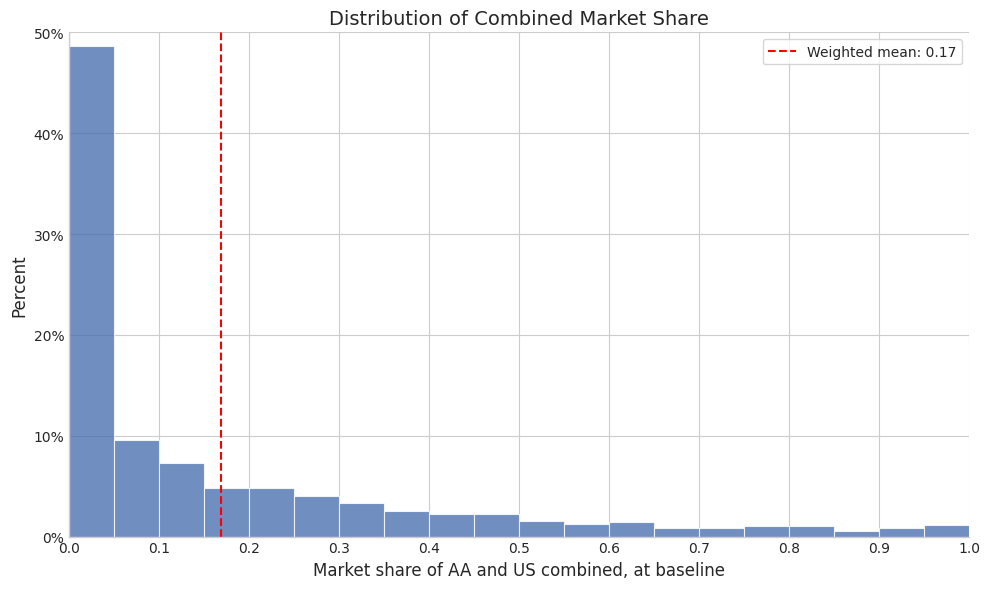

In [31]:
# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))

# Create weighted histogram
weights = data_balanced["pass_bef"] / data_balanced["pass_bef"].sum() * 100  # Convert to percentage

# Create histogram with weighted data
plt.hist(data_balanced["share_bef"], weights=weights, 
         bins=np.arange(0, 1.05, 0.05),  # 20 bins from 0 to 1
         color='#4C72B0', alpha=0.8, edgecolor='white', linewidth=0.8)

# Add vertical line for the mean
mean_share = np.average(data_balanced["share_bef"], weights=data_balanced["pass_bef"])
plt.axvline(mean_share, color='red', linestyle='--', linewidth=1.5, 
            label=f'Weighted mean: {mean_share:.2f}')

# Set labels and title
plt.xlabel("Market share of AA and US combined, at baseline", fontsize=12)
plt.ylabel("Percent", fontsize=12)
plt.title("Distribution of Combined Market Share", fontsize=14)

# Set x-axis limits and ticks
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))

# Set y-axis limits as percentage
plt.ylim(0, 50)
plt.yticks(np.arange(0, 51, 10))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Add legend
plt.legend(frameon=True)

# Clean up spines
sns.despine()

# Adjust layout
plt.tight_layout()


In [78]:
data_balanced["share_bef"]

0         0.000000
1         0.000000
2         0.000000
3         0.000000
4         0.013158
            ...   
226089    0.000000
226090    0.000000
226091    0.000000
226092    0.000000
226093    0.000000
Name: share_bef, Length: 226094, dtype: float64

In [ ]:
formula3 = "d_lnavgp ~ share_bef + lnpass_bef + return_ + stops + sharelarge_bef"
fd3 = smf.wls(formula3, data_balanced, weights=data_balanced["pass_bef"]).fit(
    cov_type="HC0"
)
fd3_small = smf.wls(
    formula3,
    data_balanced.query("smallmkt == 1"),
    weights=data_balanced.query("smallmkt == 1")["pass_bef"],
).fit(cov_type="HC0")
fd3_large = smf.wls(
    formula3,
    data_balanced.query("smallmkt == 0"),
    weights=data_balanced.query("smallmkt == 0")["pass_bef"],
).fit(cov_type="HC0")


In [76]:
stargazer = Stargazer([fd3, fd3_small, fd3_large])
stargazer.rename_covariates({"Intercept": "Constant", "lnpass_bef": "Log (Numb. of Passengers) BEFORE", "return_": "Return route", 
                             "stops":"Numb. of Stops", "sharelarge_bef": "Share of largest carrier BEFORE", "treated[T.True]": "American Airlines BEFORE"})
stargazer.custom_columns(["All markest", "Small markets", "Large markets"], [1, 1, 1])
HTML(stargazer.render_html())


**Diff-in-diffs on pooled cross-sections regeression**
* use entire unbalanced panel
* errr... after only is dropped here see later
* weighted by # passengers on market, in before period

In [68]:
data_agg = data_agg.merge(
    data_agg.loc[lambda x: x["before"] == 1]
    .assign(lnpass_bef=lambda x: np.log(x["passengers"]))
    .groupby("market")
    .agg(
        lnpass_bef=("lnpass_bef", np.nanmean),
        sharelarge_bef=("sharelargest", np.nanmean),
    )
    .reset_index(),
    on="market",
    how="left",
)


In [69]:
data_agg.groupby(["balanced", "before"]).agg({"passengers": ["sum", "count"]})


passengers        
                       sum   count
balanced before                   
False    0          457978   22851
         1          103082   28665
True     0        30186202  113047
         1        23950219  113047

In [ ]:
# treatment group defined if observed before only or both before and after


In [70]:
data_agg = data_agg.merge(
    data_agg.loc[lambda x: x["before"] == 1]
    .groupby("market")
    .agg(treatment=("AA_and_US", np.nanmean))
    .reset_index(),
    on="market",
)


In [71]:
data_agg["treatment_isna"] = data_agg["treatment"].isna()
data_agg.groupby(["treatment_isna", "balanced"]).agg({"passengers": ["sum", "count"]})


passengers        
                               sum   count
treatment_isna balanced                   
False          False        103082   28665
               True       54136421  226094

In [72]:
data_agg = data_agg.rename(columns={"return": "return_"})


In [73]:
# conditioning on observed confounders
formula4 = "lnavgp ~ (treatment + lnpass_bef + return_ + stops + sharelarge_bef)*after"

fd4 = smf.wls(formula4, data_agg, weights=data_agg["pass_bef"]).fit(cov_type="HC0")
fd4_small = smf.wls(
    formula4,
    data_agg.query("smallmkt == 1"),
    weights=data_agg.query("smallmkt == 1")["pass_bef"],
).fit(cov_type="HC0")
fd4_large = smf.wls(
    formula4,
    data_agg.query("smallmkt == 0"),
    weights=data_agg.query("smallmkt == 0")["pass_bef"],
).fit(cov_type="HC0")


In [74]:
stargazer = Stargazer([fd4, fd4_small, fd4_large])
stargazer.rename_covariates({"Intercept": "Constant"})
stargazer.custom_columns(["All markest", "Small markets", "Large markets"], [1, 1, 1])
HTML(stargazer.render_html())
